<a href="https://colab.research.google.com/github/1900690/DX-group-text/blob/main/%E3%83%91%E3%83%BC%E3%82%BB%E3%83%B3%E3%83%88%E7%B5%B1%E8%A8%88%E8%A7%A3%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍅 トマトの商品化率 統計分析ツール

このノートブックは、対照区を含めた4つの試験区（各3反復）の「商品化率」に、統計的に意味のある差（有意差）があるかどうかを判定するためのツールです。

割合（%）データ特有のクセを直し（角変換）、全体の差を確認し（分散分析）、対照区との一騎打ち（ダネット検定）または総当たり（Tukey（テューキー）法）を行うという、農業試験で最も標準的な手順を自動で行います。

---

## 🛠️ ステップ1：準備（計算道具の読み込み）
まずは、データ分析やグラフ作成に必要なPythonの「道具箱（ライブラリ）」を開きます。
左側の「▶︎」再生ボタンを押して実行してください。

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, dunnett

# 日本語表示の設定（Colab環境用）
!pip install japanize-matplotlib
import japanize_matplotlib

## 📂 ステップ2：データの読み込みと下準備

分析したいデータを読み込みます。
コードの4行目にある `読み込み方法` の文字を書き換えることで、自分のデータを使うか、練習用データを使うかを選べます。

* **"A" にした場合**：ご自身のパソコンにあるCSVファイルをアップロードできます。(項目名はサンプルの中身に従ってください)

* **"B" にした場合**：サンプルデータを自動で読み込みます。

**【ここで自動的に行われる下準備（重要）】**
読み込みと同時に、商品化率（商品果数 ÷ 全収穫果数）を計算し、**「角変換（かくへんかん、angular_transform）」**という処理を行っています。

準備ができたら「▶︎」を押して実行してください。

<table style="border: none; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; padding: 10px; vertical-align: top;">
      <img src="https://github.com/1900690/DX-group-text/raw/main/sample/sample.png" width="300">
      <div style="text-align: center;">サンプルのデータの中身</div>
    </td>
  </tr>
</table>


In [21]:
# ===================================================
# ステップ2：データの読み込み
# ===================================================

読み込み方法 = "A" # ご自身のCSVを読み込む場合は "A" のままでOKです

if 読み込み方法 == "A":
    from google.colab import files
    import io
    print("あなたのパソコンにあるCSVファイルを選択してください...")
    uploaded = files.upload()
    ファイル名 = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[ファイル名]))
    print(f"➔ 「{ファイル名}」の読み込みが完了しました！")

elif 読み込み方法 == "B":
    github_url = "https://raw.githubusercontent.com/your-username/tomato-data/main/sample_tomato.csv"
    try:
        df = pd.read_csv(github_url)
        print("➔ GitHubからサンプルのCSVファイルを読み込みました！")
    except Exception as e:
        print("（サンプルデータを直接作成しました）")
        サンプルデータ = {
            'Test area': ['control area', 'control area', 'control area', 'A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
            'Total fruit': [425, 427, 408, 408, 354, 427, 393, 414, 452, 457, 452, 444],
            'marketable fruits': [381, 387, 371, 365, 313, 363, 359, 389, 403, 431, 432, 423]
        }
        df = pd.DataFrame(サンプルデータ)

# -----------------------------------------------
# データの共通処理（新しく作る列もすべて英語で命名）
# -----------------------------------------------
# 商品化率 = marketable_rate
df['marketable_rate'] = df['marketable fruits'] / df['Total fruit']

# 角変換値 = angular_transform
df['angular_transform'] = np.arcsin(np.sqrt(df['marketable_rate']))

print("\n--- 読み込んだデータ（最初の5行分） ---")
print(df.head())

（サンプルデータを直接作成しました）

--- 読み込んだデータ（最初の5行分） ---
      Test area  Total fruit  marketable fruits  marketable_rate  \
0  control area          425                381         0.896471   
1  control area          427                387         0.906323   
2  control area          408                371         0.909314   
3             A          408                365         0.894608   
4             A          354                313         0.884181   

   angular_transform  
0           1.243209  
1           1.259738  
2           1.264907  
3           1.240164  
4           1.223537  


### ※言葉解説📐 角変換（逆正弦変換）とは

トマトの商品化率などの「割合（%）データ」を正しく統計分析するために使用した、角変換（かくへんかん）の詳しい計算式です。

#### 1. 計算式

$$Y = \arcsin\sqrt{p}$$

※文献によっては $Y = \sin^{-1}\sqrt{p}$ と書かれることもありますが、全く同じ意味です。

#### 2. 記号の意味

* **$p$ （ピー）**：元の割合データ（0.0 〜 1.0 の範囲）。例えば商品化率が 80% なら `0.80` を入れます。
* **$\sqrt{p}$ （ルート）**：その割合データの平方根（ルート）をとります。
* **$\arcsin$ （アークサイン）**：三角関数サイン（$\sin$）の逆関数です。「$\sin$ を計算すると、その数字（$\sqrt{p}$）になるような角度（ラジアン）」に逆算する数学の関数です。
* **$Y$ （ワイ）**：新しく計算された「変換後の値（角変換値）」です。

---
#### 🧐 なぜ割合（%）データに「角変換」が必要なのか？

「商品化率」や「発芽率」のような **割合（%）を表すデータ** を統計分析（分散分析）にかけるとき、なぜわざわざ難しい計算式を使って「角変換」をしなければならないのか、その理由を分かりやすく解説します。

---

#### 1. 割合データが持つ「不公平なクセ」

割合データには、**「50%付近はばらつきやすく、0%や100%に近づくほどばらつきが小さくなる」**という数学的なクセがあります。

トマトの商品化率を例に考えてみましょう。

* **平均50%のグループ**：栽培のちょっとした条件の違いで、ある反復は `30%` に下がったり、別の反復は `70%` に上がったりと、**上下に大きくばらつく（ブレる）余裕**があります。
* **平均95%のグループ**：どれだけ調子が良くても `100%` という天井があるため、データのばらつきは `92%〜98%` のように、**必然的に狭い範囲に押し込められて小さく**なります。



このように、データの「平均値の大きさ」によって「ばらつき（ブレ幅）の大きさ」が勝手に変わってしまうのが、割合データの最大の特徴です。

---

#### 2. 統計の裁判官（分散分析）の「絶対ルール」

ステップ3で行う「分散分析（ANOVA）」という統計のジャッジ方法には、実は以下のような大前提（絶対ルール）があります。

> ⚖️ **分散分析のルール（等分散性の仮定）**
> 「比べるすべてのグループの『データのばらつきの幅』が、だいたい同じくらいでなければ、正しくジャッジできません」

もし、ばらつきが「大きいグループ（50%付近）」と「小さいグループ（95%付近）」をそのまま混ぜて分散分析にかけてしまうと、裁判官は正しい計算ができなくなり、**「本当は差があるのに、差がない」と間違った判定を下してしまうリスク**が高まります。

---

#### 3. 角変換が起こす「魔法（分散の安定化）」

この不公平なデータを救うのが **「角変換（逆正弦変換）」** です。

角変換の数式（$\arcsin\sqrt{p}$）を通すと、以下のような魔法が起きます。
* **100%や0%に近い「狭いばらつき」** ➔ ググッと引き伸ばされて広くされる
* **50%付近の「広いばらつき」** ➔ そのままキープされる

この結果、すべての試験区の **「ばらつきの幅（分散）」が均一に整い、お互いを平等に比較できる状態** になります。

---
#### 💻 Pythonコードとの繋がり

プログラムの上のセルで実行する以下のコードは、上記の数式をそのまま命令したものです。

```python
df['angular_transform'] = np.arcsin(np.sqrt(df['marketable_rate']))

## ⚖️ ステップ3：全体の確認（分散分析：ANOVA）

まずは、対照区・試験区A・試験区B・試験区Cの**「4つのグループ全体の中に、そもそも意味のある違い（ただの偶然じゃない差）があるか？」**をざっくり判定します。

* **p値が 0.05 より小さい場合**：どこかの区に確実に差があります！（次のステップへ進みます）
* **p値が 0.05 以上の場合**：意味のある差はありません。今回の試験では処理による効果は確認できなかった、という結論になります。

In [22]:
# 'Test area' ごとに 'angular_transform'（角変換値）のデータを抽出
groups = [df[df['Test area'] == name]['angular_transform'].values for name in df['Test area'].unique()]

# 分散分析の実行
f_stat, p_anova = f_oneway(*groups)

print(f"分散分析のp値: {p_anova:.4f}")
if p_anova < 0.05:
    print("結果：試験区間に有意な差があります。次のダネット検定に進みます。")
else:
    print("結果：有意な差はありません。")

分散分析のp値: 0.0034
結果：試験区間に有意な差があります。次のダネット検定に進みます。


## ⚔️ ステップ4：対照区との一騎打ち（ダネット検定）

ステップ3で「全体に違いがある」とわかったら、いよいよ本番です。
基準となる「対照区」に対して、試験区A、B、Cがそれぞれ本当に勝っているか（または負けているか）を1対1で判定します。

* **p値が 0.05 より小さい区**：対照区に対して**「有意差あり（確実に効果があった）」**と言えます。
* ダネット検定は「対照区との比較」に特化しているため、農業試験において非常に信頼できる判定方法です。

In [23]:
# 対照区と各試験区の 'angular_transform'（角変換値）をそれぞれ取り出す
control_group = df[df['Test area'] == 'control area']['angular_transform'].values
treat_A = df[df['Test area'] == 'A']['angular_transform'].values
treat_B = df[df['Test area'] == 'B']['angular_transform'].values
treat_C = df[df['Test area'] == 'C']['angular_transform'].values

# ダネット検定の実行
res = dunnett(treat_A, treat_B, treat_C, control=control_group)

print("--- ダネット検定の結果 ---")
names = ['A', 'B', 'C']
for name, p in zip(names, res.pvalue):
    star = "*" if p < 0.05 else "なし"
    print(f"control area vs {name}: p値 = {p:.4f} ({star})")

--- ダネット検定の結果 ---
control area vs A: p値 = 0.2391 (なし)
control area vs B: p値 = 0.7312 (なし)
control area vs C: p値 = 0.0138 (*)


## 📊 ステップ5：グラフで視覚的に確認（箱ひげ図）

最後に、データのばらつき具合を目で見て確認するために「箱ひげ図」を作成します。

* 箱の真ん中の線が「中央値」です。
* 箱の大きさが「ばらつき」を表しています。
* 統計の結果（ステップ4）と、実際のグラフの見た目（明らかに商品化率が上がっているか等）が一致しているかを確認しましょう。

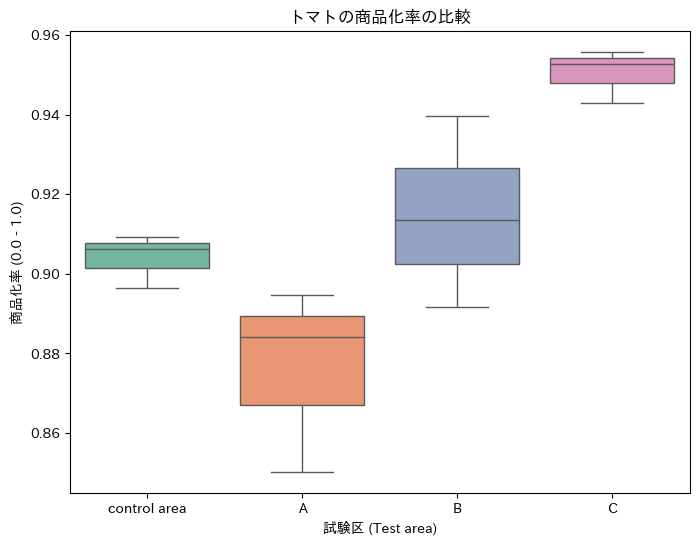

In [24]:
#グラフで可視化
plt.figure(figsize=(8, 6))
sns.boxplot(x='Test area', y='marketable_rate', data=df, hue='Test area', palette='Set2', legend=False)

plt.title('トマトの商品化率の比較')
plt.ylabel('商品化率 (0.0 - 1.0)')
plt.xlabel('試験区 (Test area)')
plt.show()

### ※言葉解説 📦 箱ひげ図で見る「有意差」とは

統計の裁判官（分散分析やダネット検定）は、単に「平均値のズレ」を見るだけでなく、**「データのばらつき（箱の縦の長さ）に対して、そのズレが十分に大きいか」**を厳しくチェックしています。

箱ひげ図を見ると、難しい計算結果を見なくても「有意差がありそうかどうか」を直感的に予想することができます。

---

#### 🌟 1. 有意差がある（確実に効果がある）場合
処理の効果がはっきりと出ているときは、グラフが以下のような特徴を持ちます。

* **箱が上下に分離している**：一方の箱が、もう一方よりも明らかに高い（または低い）位置にズレている。
* **重なりが少ない**：真横に線を引いたとき、2つの箱が被さるエリアがほとんどない。
* **箱がコンパクト（ばらつきが小さい）**：箱の縦の長さがギュッと短くまとまっていると、少しのズレでも「確実な差だ！」と判定されやすくなります。

---

#### 🌧️ 2. 有意差がない（偶然の誤差かもしれない）場合
たとえ「平均値（箱の中の線）」がズレていても、以下のような場合は「有意差なし」と判定されてしまいます。

* **箱が大きく重なっている**：箱同士が同じような高さの範囲にどっしりと被っている。
* **箱が縦に長い（ばらつきが大きい）**：箱やヒゲが上下にビローンと長く伸びている状態。

---

#### 💡 ここが農業試験のポイント（統計のジレンマ）
たとえ平均値（収量や商品化率）が大きくアップしていても、株ごとの**データのばらつき（箱の長さ）が大きすぎる**と、統計の裁判官は次のように考えます。

> ⚖️ **「うーん、これだけ広範囲にデータが散らばりやすい環境なら、今回のズレもただの偶然（ラッキー）の範囲内だね。確実な効果とは言えません！」**

このように、有意差を出すためには「平均を上げる」ことと同じくらい**「ばらつきを減らす（箱を小さくする）」**ことが重要です。
農業試験において、「反復数を増やす」「ハウス内の栽培環境を均一にする」ことがいかに大切かが、箱ひげ図を見るとよく分かります。

# 🥊 Tukey（テューキー）法による多重比較検定

「対照区との比較」だけでなく、「試験区A vs 試験区B」「試験区B vs 試験区C」など、**すべてのグループを総当たりで比較**して有意差を出したい場合は、TukeyのHSD（Honestly Significant Difference）検定を使用します。

## 1. Tukey法の計算式（q統計量）

Tukey法では、比べたい2つのグループの平均値の差が「誤差のばらつき」に対してどれくらい大きいかを示す **$q$値（スチューデント化された範囲統計量）** を計算します。

$$q = \frac{|\bar{Y}_A - \bar{Y}_B|}{\sqrt{\frac{MS_w}{n}}}$$

* **$\bar{Y}_A, \bar{Y}_B$**：比較する2つのグループの平均値（※ここでは角変換した後の平均値）
* **$MS_w$（Mean Square Within）**：分散分析（ANOVA）で計算された、グループ内の誤差のばらつき（群内平均平方）
* **$n$**：1グループあたりの反復数（今回は $n=3$）

## 2. 判定の仕組み

計算した $q$値 が、統計の表であらかじめ決まっている「基準となる限界値」よりも大きければ、**「この2つのグループ間には、統計的に意味のある差（有意差）がある！」** と判定されます。総当たり戦になるため、偶然に差が出てしまうのを防ぐよう、判定基準が自動的に厳しく調整されるのが特徴です。

--- Tukey法（総当たり戦）の結果 ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1    group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------
     A            B   0.0644 0.1059 -0.0128  0.1415  False
     A            C   0.1345 0.0023  0.0573  0.2117   True
     A control area   0.0436 0.3354 -0.0335  0.1208  False
     B            C   0.0701 0.0756 -0.0071  0.1473  False
     B control area  -0.0207 0.8248 -0.0979  0.0564  False
     C control area  -0.0908 0.0228  -0.168 -0.0137   True
----------------------------------------------------------
--------------------------------------------------


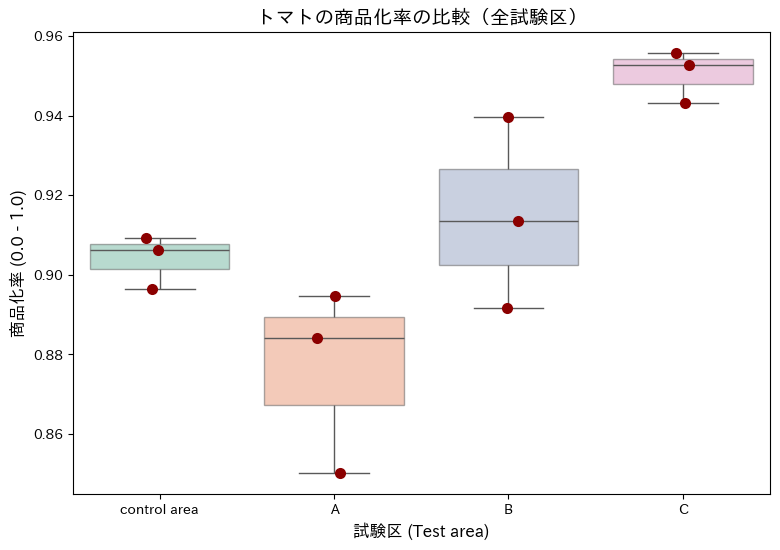

In [25]:
# ===================================================
# 【代替】ステップ4：総当たり戦（Tukey法）の実行
# ===================================================
# Tukey法を使うための専用の道具を読み込みます
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("--- Tukey法（総当たり戦）の結果 ---")
# データ（角変換値）、グループ分け（Test area）、有意水準（アルファ=0.05）を指定して計算します
tukey_result = pairwise_tukeyhsd(endog=df['angular_transform'], groups=df['Test area'], alpha=0.05)

# 結果の一覧表を表示します
# 'reject'（棄却）の列が 'True' になっているペアに「有意差あり」という意味になります
print(tukey_result)
print("-" * 50)


# ===================================================
# 【代替】ステップ5：グラフで視覚的に確認（箱ひげ図＋実データ点）
# ===================================================
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

plt.figure(figsize=(9, 6))

# 1. 箱ひげ図を描く（箱の色を薄くして見やすくします）
sns.boxplot(x='Test area', y='marketable_rate', data=df,
            hue='Test area', palette='Set2', legend=False,
            boxprops=dict(alpha=0.5)) # alphaで透明度を調整

# 2. 実際のデータ点（3反復のそれぞれの点）を上に重ねて打つ（ストリッププロット）
# 反復数が少ない（3回）場合は、点が直接見えた方が説得力が増します
sns.stripplot(x='Test area', y='marketable_rate', data=df,
              color='darkred', size=8, jitter=True)

plt.title('トマトの商品化率の比較（全試験区）', fontsize=14)
plt.ylabel('商品化率 (0.0 - 1.0)', fontsize=12)
plt.xlabel('試験区 (Test area)', fontsize=12)

# グラフを表示
plt.show()

### ※言葉解説 ⚖️ Tukey法とダネット検定で「結果が違う」のはなぜ？

同じデータを使っているのに、検定手法を変えると「有意差あり・なし」の結果が変わることがあります。これは、統計の裁判官が設けている**「誤審（フライング）を防ぐためのハードルの高さ」**が違うからです。

#### 1. 「試合数（比較回数）」が違う
4つのグループ（対照区、A、B、C）を比較する場合の「試合数」を数えてみましょう。

* **🛡️ ダネット検定（対照区とのみ比較）**
  1. 対照区 vs A
  2. 対照区 vs B
  3. 対照区 vs C
  ➔ **合計 3試合**

* **⚔️ Tukey法（総当たり戦）**
  1. 対照区 vs A　2. 対照区 vs B　3. 対照区 vs C
  4. A vs B　5. A vs C　6. B vs C
  ➔ **合計 6試合**

#### 2. 試合が増えるほど「まぐれ当たり」が増える（多重性の問題）
統計の検定（p < 0.05）は、「5%の確率で、本当は差がないのに『差がある！』と勘違い（誤審）してしまう」というルールで動いています。

* 1試合だけなら、誤審の確率は5%です。
* しかし、Tukey法のように**6試合も総当たり戦を行うと、「6試合のうち、どこか1つくらいでまぐれ当たり（誤審）が起きてしまう確率」が跳ね上がってしまいます。**（およそ26%まで上がります）

#### 3. 裁判官はハードルを高くする
「全体としての誤審の確率」を絶対に5%以内に抑えたい裁判官は、試合数が多いときには次のようにルールを変えます。

> 👨‍⚖️ **裁判官：**
> 「Tukey法は試合数（6試合）が多いから、まぐれ当たりを防ぐために、**『差がある』と認めるためのハードルを高く（厳しく）するぞ！** ダネットは3試合だけだから、そこまで厳しくしなくていいよ」

#### 📝 結論：使い分けのセオリー
このため、ダネット検定ではギリギリ「有意差あり」と判定された小さな効果が、厳しいTukey法では「有意差なし」と跳ね返されてしまう現象が起きます。

* **「対照区に対して効果があったか」だけを証明したい場合：**
  無駄な試合を減らしてハードルを下げ、小さな差も見つけやすい（検出力が高い）**ダネット検定**を使うのが大正解です。
* **「AとBの違い」など、すべての組み合わせを調べたい場合：**
  ハードルが厳しくなることを覚悟の上で、**Tukey法**を使います。

###※言葉解説 🎯 「p < 0.05」は同じなのに、なぜハードルの高さが違うのか？

ダネット検定でもTukey法でも、最終的な判定には「p < 0.05（5%ルールのクリア）」という同じ看板が使われます。それなのに「Tukey法の方が厳しい」と言われると、不思議に思いますよね。

実は、**「p < 0.05」というのは越えるべき「ハードルの高さ（点数）」ではなく、裁判官が守らなければならない「全体のルール」**なのです。

---

#### 🎲 1. 試合数が増えると「まぐれ当たり」が増える
「本当は差がないのに、まぐれで『差がある！』と誤審してしまう確率」について考えてみます。

サイコロを1回振って「1」が出る確率は約16%ですが、**6回振れば「どこかで1回でも『1』が出る確率」は約66%**に跳ね上がります。何度もチャンスがあれば、まぐれが起きる確率は上がります。

統計の裁判官も同じ問題に直面します。（1試合の誤審率を5%とした場合）
* **ダネット検定（3試合）**：3回も試合をすると、どこかで誤審する確率は **約14%** に上がる。
* **Tukey法（6試合）**：総当たりで6回も試合をすると、どこかで誤審する確率は **約26%** にも跳ね上がる。

---

#### 👨‍⚖️ 2. 裁判官の解決策 ＝「内部のハードルを上げる」
裁判官は**「全体の誤審率を、絶対にトータルで 5%（p < 0.05）以内に抑えろ！」**という絶対ルールを課されています。

しかしそのままでは、試合数の多いTukey法はルール違反（26%の誤審）になってしまいます。そこで裁判官は、裏でコッソリと**「1試合あたりの合格基準（ハードルの高さ）」**を厳しく引き上げます。

* **🛡️ ダネット検定（3試合）の場合**
  「全体で5%に収めたいから、1試合ごとの基準は **p < 0.017** くらいまで厳しくしておこう」
* **⚔️ Tukey法（6試合）の場合**
  「全体で5%に収めるには、1試合ごとの基準を **p < 0.008** くらいまで超絶厳しくしないとダメだ！」

---

#### 📝 結論のまとめ
私たちが最終的に見る結果は、どちらも**「調整済みの p < 0.05」**という共通のラベルが貼られています。

しかし、その「p < 0.05の合格ラベル」をもらうために、**裏で実際に超えなければならなかった「本当のハードルの高さ（限界値）」は、試合数の多いTukey法の方がはるかに高く（厳しく）設定されている**のです。

これが、同じデータで同じ「p < 0.05」の基準を使っているのに、検定手法によって結果が変わってしまう（Tukey法だと有意差が消えてしまう）最大の理由です。